In [1]:
import numpy as np
import matplotlib.pyplot as plt

Mean: 1.40043905
Median: 1.69673
Std: 0.3773387017491679
Min: 0.833439
Max: 1.8916
95th percentile: 1.776915
99th percentile: 1.8594349000000001
Number of outliers: 0


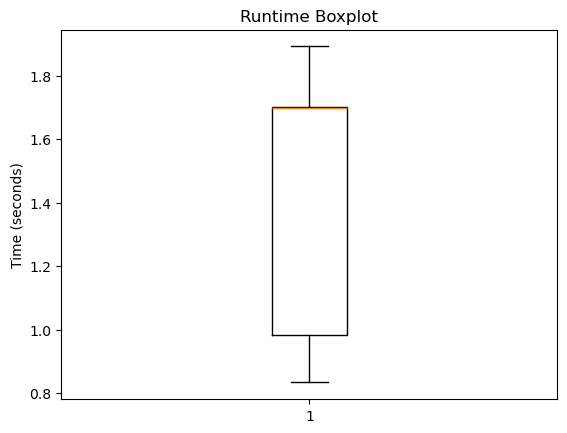

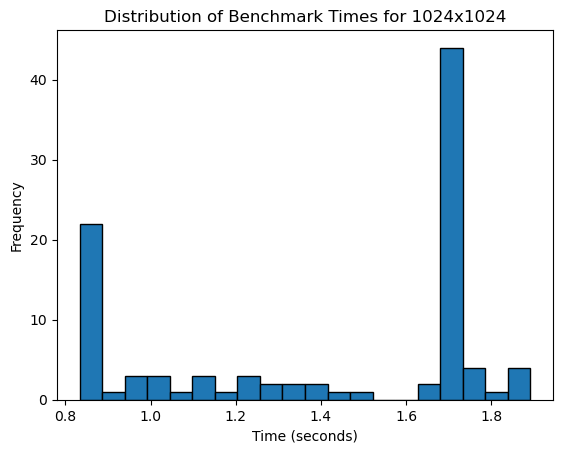

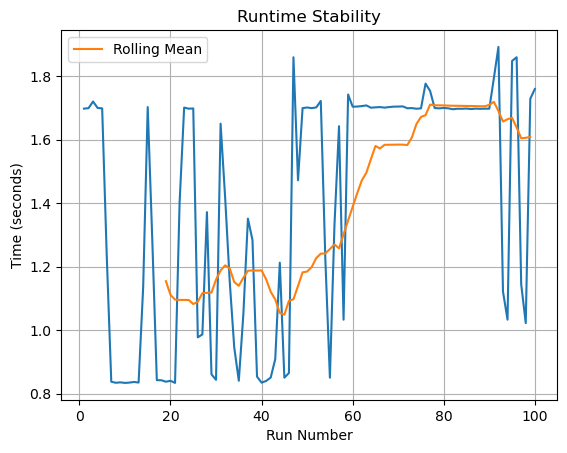

In [20]:
size = '1024x1024'  # Change this to the desired size (e.g., '64x64', '128x128', etc.)
filename = f'timing_{size}.csv'
data = np.genfromtxt(filename, delimiter=',', skip_header=1)

counts, bin_edges = np.histogram(data[:, 1], bins=20)

times = data[:,1]

print("Mean:", np.mean(times))
print("Median:", np.median(times))
print("Std:", np.std(times))
print("Min:", np.min(times))
print("Max:", np.max(times))
print("95th percentile:", np.percentile(times,95))
print("99th percentile:", np.percentile(times,99))

q1 = np.percentile(times,25)
q3 = np.percentile(times,75)
iqr = q3 - q1

outliers = times[(times < q1 - 1.5*iqr) | (times > q3 + 1.5*iqr)]
print("Number of outliers:", len(outliers))

plt.boxplot(times)
plt.title("Runtime Boxplot")
plt.ylabel("Time (seconds)")
plt.show()

plt.bar(bin_edges[:-1], counts, width=np.diff(bin_edges), edgecolor='black', align='edge')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Benchmark Times for {size}')
plt.show()

plt.plot(data[:, 0], data[:, 1], linestyle='-')
plt.xlabel('Run Number')
plt.ylabel('Time (seconds)')
plt.title(f'Benchmark Times for {size} Over Iterations')
plt.grid()
#plt.show()

window = 20
rolling_mean = np.convolve(times, np.ones(window)/window, mode='valid')

#plt.plot(times, alpha=0.4, label="Raw")
plt.plot(range(window-1,len(times)), rolling_mean, label="Rolling Mean")
plt.legend()
plt.title("Runtime Stability")
plt.ylabel("Time (seconds)")
plt.show()

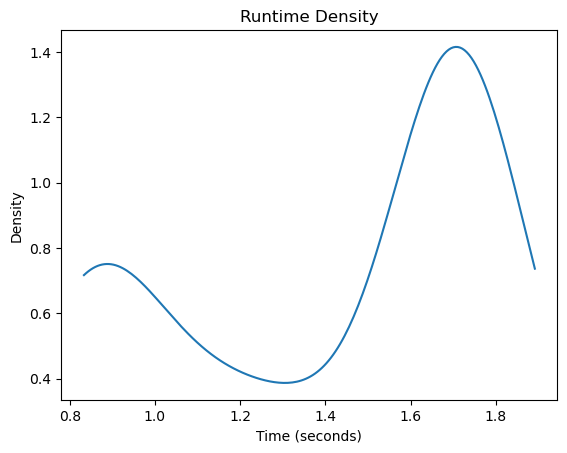

In [21]:
from scipy.stats import gaussian_kde

kde = gaussian_kde(times)
x = np.linspace(min(times), max(times), 200)

plt.plot(x, kde(x))
plt.title("Runtime Density")
plt.xlabel("Time (seconds)")
plt.ylabel("Density")
plt.show()